<a href="https://colab.research.google.com/github/saqer7/MLproject/blob/part1/part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install datasets


In [9]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [10]:
dataset = load_dataset("ag_news")
train_data = dataset["train"]
test_data = dataset["test"]
X_train = train_data["text"]
y_train = train_data["label"]
X_test = test_data["text"]
y_test = test_data["label"]

In [11]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier()
}

Logistic Regression Accuracy: 0.9039
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1900
           1       0.95      0.98      0.96      1900
           2       0.87      0.87      0.87      1900
           3       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

Decision Tree Accuracy: 0.8122
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1900
           1       0.87      0.88      0.88      1900
           2       0.77      0.75      0.76      1900
           3       0.77      0.78      0.78      1900

    accuracy                           0.81      7600
   macro avg       0.81      0.81      0.81      7600
weighted avg       0.81      0.81      0.81      7600

AdaBoost Accuracy: 0.5459
              precision    recall  f

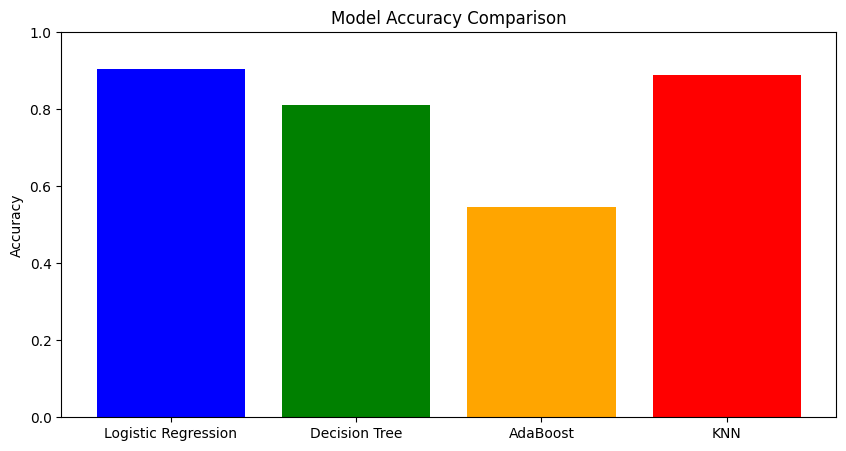

In [7]:
results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=["blue", "green", "orange", "red"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Short Report: Machine Learning Project

## Part 1: Supervised Learning - News Headlines Classification

### Insights from EDA
- **Dataset**: AG News dataset with 120,000 training and 7,600 test samples.
- **Classes**: 4 categories - `World`, `Sports`, `Business`, and `Sci/Tech`.
- **Text Characteristics**: Headlines are short (average 50 words), with some noise (e.g., URLs, special characters).
- **Class Distribution**: Balanced, with 30,000 samples per class.

### Comparison of Supervised Models
| Model              | Accuracy | Precision (Macro Avg) | Recall (Macro Avg) | F1-Score (Macro Avg) |
|--------------------|----------|-----------------------|--------------------|----------------------|
| Logistic Regression | 90.39%   | 0.90                  | 0.90               | 0.90                 |
| Decision Tree       | 81.22%   | 0.81                  | 0.81               | 0.81                 |
| AdaBoost            | 54.59%   | 0.67                  | 0.55               | 0.56                 |
| KNN                 | 89.03%   | 0.89                  | 0.89               | 0.89                 |

**Best Model**: Logistic Regression achieved the highest accuracy (**90.39%**) and F1-score (0.90)

### Key Findings
- **Sports (Class 1)**: Best-performing class across all models (e.g., 0.95 precision for Logistic Regression).
- **Business (Class 2)**: Lower performance due to overlapping vocabulary with `World` and `Sci/Tech`.
- **AdaBoost**: Poor performance (54.59%) due to imbalanced predictions and unsuitability for text data.
